# Modelo regresión logistica undersampling

In [86]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold, cross_validate
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,classification_report, confusion_matrix, ConfusionMatrixDisplay,roc_auc_score

## Modelo regresión logistica undersampling entrenamiento

Oversampling El intervalo de confianza es: [0.6179844848124634,0.6692055999129511]
La precisión del modelo con el conjunto de entrenamiento es de: 0.5585333333333333
Modelo guardado correctamente
¿Tiene coef_?: True
Clases: ['no' 'yes']
N columnas modelo: 14
              precision    recall  f1-score   support

           0       0.33      0.49      0.39      4433
           1       0.73      0.59      0.65     10567

    accuracy                           0.56     15000
   macro avg       0.53      0.54      0.52     15000
weighted avg       0.61      0.56      0.58     15000



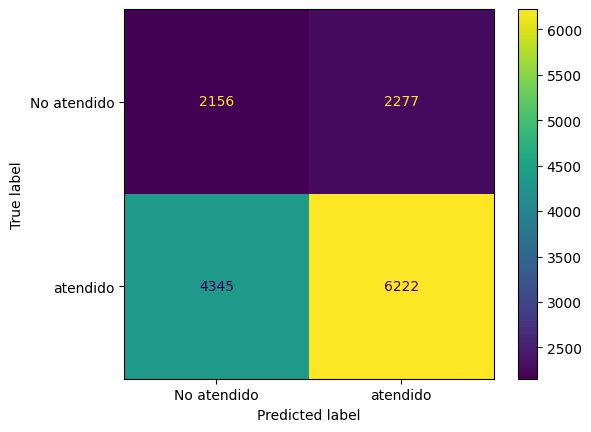

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df = pd.read_csv('healthdemand.csv')

# 1. Convertir a datetime (las que no se puedan parsear quedan como NaT)
df['fecha_hora_turno'] = pd.to_datetime(df['fecha_hora_turno'], errors='coerce')
df['fecha_solicitud']  = pd.to_datetime(df['fecha_solicitud'],  errors='coerce')

# 2. Eliminar filas donde alguna de esas dos columnas sea NaT
df = df.dropna(subset=['fecha_hora_turno', 'fecha_solicitud'])

# 3. (Opcional) Resetear el índice
df = df.reset_index(drop=True)
df = df.dropna()

df1 = df.copy()

df1["fecha_hora_turno"] = pd.to_datetime(df1["fecha_hora_turno"])
df1["fecha_solicitud"] = pd.to_datetime(df1["fecha_solicitud"])

# Separar fecha y hora de "fecha_hora_turno"
df1["fecha_turno"] = df1["fecha_hora_turno"].dt.date
df1["hora_turno"]  = df1["fecha_hora_turno"].dt.time

# Separar fecha y hora de "fecha_solicitud"
df1["fecha_solicitud_dia"] = df1["fecha_solicitud"].dt.date
df1["hora_solicitud"]      = df1["fecha_solicitud"].dt.time
# Limpiar nombres de columnas por si hay espacios
df1.columns = df1.columns.str.strip()

# Eliminar sin modificar df1
df1Cop = df1.drop(columns=['fecha_hora_turno', 'fecha_solicitud'], errors='ignore')
df1['atendido'] = df['estado_turno'].apply(lambda x: 'yes' if x == 'Atendido' else 'no')

# Tipos y limpieza
df1["fecha_hora_turno"] = pd.to_datetime(df1["fecha_hora_turno"])
df1["fecha_solicitud"]  = pd.to_datetime(df1["fecha_solicitud"])

for c in ["especialidad","sede","tipo_atencion","estado_turno","atendido"]:
    df1[c] = df1[c].astype(str).str.strip()

# Target binaria
#df1["y"] = (df1["atendido"].str.lower() == "no").astype(int)

# Features a nivel turno
df1["fecha"]      = df1["fecha_hora_turno"].dt.date
df1["hora"]       = df1["fecha_hora_turno"].dt.hour
df1["dia_semana"] = df1["fecha_hora_turno"].dt.dayofweek
df1["mes"]        = df1["fecha_hora_turno"].dt.month
df1["lead_time"]  = (df1["fecha_hora_turno"] - df1["fecha_solicitud"]).dt.days

df1["franja"] = pd.cut(df1["hora"], bins=[6, 12, 20, 24], labels=["Mañana","Tarde","Noche"], include_lowest=True).astype(str)

# Features agregadas por grupo (SIN tocar y)
df2 = (df1.groupby(["fecha","especialidad","sede","franja"], observed=True).agg(turnos_totales = ("id_turno","count"), lead_time_prom = ("lead_time","mean"), lead_time_max  = ("lead_time","max"),).reset_index())

# Unir features agregadas al nivel turno
df3 = df1.merge(df2, on=["fecha","especialidad","sede","franja"], how="left", validate="many_to_one")
drop_cols = ["atendido", "estado_turno", "id_turno", "id_profesional", "fecha_hora_turno", "fecha_solicitud", "fecha_turno", "hora_turno", "fecha_solicitud_dia",
             "hora_solicitud", "fecha","hora","lead_time_prom","mes","lead_time","turnos_totales","lead_time_max",]# target y columnas que la delatan, IDs, no aportan, timestamps crudos, si están duplicadas con otras, fecha cruda: mejor usar mes/dia_semana
x1 = df3.drop(columns=[c for c in drop_cols if c in df3.columns])
y1 = df3["atendido"]
xVar = x1
yVarObj = y1

columCateg = xVar.select_dtypes(include='object').columns.tolist()

oneHot = make_column_transformer((OneHotEncoder(drop='if_binary', sparse_output=False), columCateg), remainder='passthrough', verbose_feature_names_out=False)
xEncoded = oneHot.fit_transform(xVar)
xBinDF = pd.DataFrame(xEncoded, columns=oneHot.get_feature_names_out(xVar.columns))

encoder = LabelEncoder()
yVarObjBin = encoder.fit_transform(yVarObj)
dfBin = pd.concat([pd.DataFrame({'atendido': yVarObjBin}), xBinDF], axis=1)

x = dfBin.drop(columns=['atendido'])
y = dfBin['atendido']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)
##### validación cruzada con sensibilidad

def intervaloConfianza(resultados):
    promedio = resultados['test_score'].mean()
    desviStd = resultados['test_score'].std()
    return f'El intervalo de confianza es: [{promedio-2*desviStd},{min(promedio+2*desviStd,1)}]'

oversampling = SMOTE()
xBal,yBal = oversampling.fit_resample(x_train,y_train)

#### Modelo regresión logistica oversampling
mdRgLnOver = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000, class_weight=None, C=10, penalty='l1')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=5)
kf = KFold(n_splits=5, shuffle=True, random_state=5)
pipeline = imbpipeline([('oversample', SMOTE()),('Regresión lineal', mdRgLnOver)])
cvResultados = cross_validate(pipeline, x, y, cv=skf, scoring='recall')
print(f'Oversampling {intervaloConfianza(cvResultados)}')

mdRgLnOver.fit(xBal, yBal)
print(f'La precisión del modelo con el conjunto de entrenamiento es de: {mdRgLnOver.score(x_test,y_test)}')

with open('/content/mdRgLnOver.pkl', 'wb') as f:
    pickle.dump(mdRgLnOver, f)

with open('/content/modelOnehotencoder.pkl', 'wb') as f:
    pickle.dump(oneHot, f)

with open('/content/labelEncoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

with open('/content/columnas_modelo.pkl', 'wb') as f:
    pickle.dump(list(x.columns), f)

print("Modelo guardado correctamente")
print("¿Tiene coef_?:", hasattr(mdRgLnOver, 'coef_'))
print("Clases:", encoder.classes_)
print("N columnas modelo:", len(x.columns))

yPrevisto = mdRgLnOver.predict(x_test)
print(classification_report(y_test,yPrevisto))
ConfusionMatrixDisplay.from_predictions(y_test,yPrevisto, display_labels=['No atendido','atendido'])
plt.show()
#plt.savefig('matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.close()  # libera memoria

In [88]:
importancias = np.abs(mdRgLnOver.coef_[0])
nombres = x_train.columns  # si x_train es DataFrame

dfRgLnOver = (
    pd.DataFrame({'feature': nombres, 'importancia': importancias})
      .sort_values('importancia', ascending=False)
      .reset_index(drop=True)
)

top15 = dfRgLnOver.head(15)
print(top15)

                        feature  importancia
0        especialidad_Oncología     0.522524
1      especialidad_Psiquiatría     0.513457
2              sede_Sede Centro     0.041252
3        tipo_atencion_Urgencia     0.039404
4                  franja_Tarde     0.039386
5                 sede_Sede Sur     0.034597
6    especialidad_Traumatología     0.021904
7                    dia_semana     0.021636
8        especialidad_Pediatría     0.012014
9   especialidad_Clínica Médica     0.009469
10    tipo_atencion_Primera vez     0.007584
11     especialidad_Cardiología     0.002506
12        tipo_atencion_Control     0.000000
13              sede_Sede Norte     0.000000


In [89]:
fig = px.histogram(
    dfRgLnOver.head(15),
    x='feature',
    y='importancia',
    text_auto='.3f',
    histfunc='sum'
)
fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()

In [90]:
for col in x1.columns:
  print(f"valores únicos en la columna'{col}': {x1[col].nunique()}")
  if x1[col].nunique() < 50:
    print(x1[col].unique())
    print('-' * 50)
print(f"valores únicos en la columna'{y1.name}': {y1.nunique()}")
if y.nunique() < 50:
  print(y.unique())
  print('-' * 50)

valores únicos en la columna'especialidad': 6
['Oncología' 'Traumatología' 'Pediatría' 'Clínica Médica' 'Psiquiatría'
 'Cardiología']
--------------------------------------------------
valores únicos en la columna'sede': 3
['Sede Norte' 'Sede Centro' 'Sede Sur']
--------------------------------------------------
valores únicos en la columna'tipo_atencion': 3
['Control' 'Urgencia' 'Primera vez']
--------------------------------------------------
valores únicos en la columna'dia_semana': 7
[0 1 2 3 4 5 6]
--------------------------------------------------
valores únicos en la columna'franja': 2
['Mañana' 'Tarde']
--------------------------------------------------
valores únicos en la columna'atendido': 2
[1 0]
--------------------------------------------------


In [91]:
import pickle
import pandas as pd
import numpy as np


# CARGAR ARTEFACTOS GUARDADOS

with open('/content/mdRgLnOver.pkl', 'rb') as f:
    modelo = pickle.load(f)

with open('/content/modelOnehotencoder.pkl', 'rb') as f:
    oneHot = pickle.load(f)

with open('/content/labelEncoder.pkl', 'rb') as f:
    labelEnc = pickle.load(f)

with open('/content/columnas_modelo.pkl', 'rb') as f:
    columnas_modelo = pickle.load(f)


# VERIFICACIÓN RÁPIDA

print("Modelo entrenado:", hasattr(modelo, 'coef_'))
print("Clases del LabelEncoder:", labelEnc.classes_)
print("Columnas esperadas por el encoder:", list(oneHot.feature_names_in_))
print("N° columnas que espera el modelo:", len(columnas_modelo))
print("-" * 60)


# DATOS DE PRUEBA (mismas 7 features que vio el modelo)

datos_prueba = pd.DataFrame([{
    'especialidad'  : 'Pediatría',
    'sede'          : 'Sede Centro',
    'tipo_atencion' : 'Control',
    'dia_semana'    : 4,
    'franja'        : 'Mañana'
}])

# Reordenar columnas EXACTAMENTE como las vio el encoder en el fit
datos_prueba = datos_prueba[list(oneHot.feature_names_in_)]


# CODIFICAR (texto -> números)

x_encoded = oneHot.transform(datos_prueba)
x_df = pd.DataFrame(x_encoded, columns=oneHot.get_feature_names_out(datos_prueba.columns))

# Reordenar columnas EXACTAMENTE como las vio el modelo
x_df = x_df[columnas_modelo]


# PREDICCIÓN

pred  = modelo.predict(x_df)[0]
proba = modelo.predict_proba(x_df)[0]

etiqueta = labelEnc.inverse_transform([pred])[0]
probabilidades = dict(zip(labelEnc.classes_, proba))

prob_atendido    = probabilidades['yes']   # atención
prob_no_atendido = probabilidades['no']    # abandono


# RESULTADOS

print(f"Predicción: {'Atendido' if etiqueta == 'yes' else 'No atendido'}")
print(f"Probabilidad de Atendido:    {prob_atendido:.2%}")
print(f"Probabilidad de No atendido: {prob_no_atendido:.2%}")

Modelo entrenado: True
Clases del LabelEncoder: ['no' 'yes']
Columnas esperadas por el encoder: ['especialidad', 'sede', 'tipo_atencion', 'dia_semana', 'franja']
N° columnas que espera el modelo: 14
------------------------------------------------------------
Predicción: No atendido
Probabilidad de Atendido:    49.68%
Probabilidad de No atendido: 50.32%
